**Alishba Bacha**

**2022088**

**Lab 4&5 Task Solution**

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


Loading Dataset

In [12]:
df = pd.read_csv('gender_classification_v7.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


Data Preprocessing

In [13]:
df.isnull().sum()

,0
long_hair,0
forehead_width_cm,0
forehead_height_cm,0
nose_wide,0
nose_long,0
lips_thin,0
distance_nose_to_lip_long,0
gender,0


In [14]:
scaler_standard = StandardScaler()
X = df[['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide', 'nose_long', 'lips_thin','distance_nose_to_lip_long']]
df_standard_scaled = scaler_standard.fit_transform(X)

In [15]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
y = df['gender']
y = (y - np.mean(y)) / np.std(y)

In [16]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

**Neural Network Construction**



*   Build A Neural Network

In [28]:
def create_optimized_model(learning_rate=0.001, optimizer_type='adam',dropout_rate = 0.3):
    model = Sequential()

    model.add(Dense(128, input_dim=X_train.shape[1], kernel_initializer='he_normal', activation='relu'))

    model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    model.add(Dense(2, activation='softmax'))

    if optimizer_type == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_type == 'sgd':
        optimizer = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])


    return model


In [29]:
learning_rate = 0.001
dropout_rate = 0.3
optimizer_type = 'adam'
lambda_l2 = 0.01
batch_size = 32
epochs = 10

input_shape = X_train.shape[1]

model = create_optimized_model(learning_rate=learning_rate, optimizer_type=optimizer_type)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
history = model.fit(X_train, y_train, validation_data=(X_train_val, y_train_val), epochs=10, batch_size=32)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0000e+00 - loss: 0.2983 - val_accuracy: 0.0000e+00 - val_loss: 1.3925
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0000e+00 - loss: 0.1043 - val_accuracy: 0.0000e+00 - val_loss: 0.6147
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0000e+00 - loss: 0.1165 - val_accuracy: 0.0000e+00 - val_loss: 0.2010
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 0.1011 - val_accuracy: 0.0000e+00 - val_loss: 0.2936
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0000e+00 - loss: 0.1065 - val_accuracy: 0.0000e+00 - val_loss: 0.3685
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0955 - val_accuracy: 0.0000e+00 - val_loss: 0.0983
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.1030 - val_accuracy: 0.0000e+00 - val_loss: 0.0687
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy:

In [32]:
def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title}: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title}: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


Experiment 1: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'optimizer_type': 'adam'}
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.0000e+00 - loss: 0.3107 - val_accuracy: 0.0000e+00 - val_loss: 1.6440 - learning_rate: 0.0010
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1073 - val_accuracy: 0.0000e+00 - val_loss: 0.1438 - learning_rate: 0.0010
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1067 - val_accuracy: 0.0000e+00 - val_loss: 0.1178 - learning_rate: 0.0010
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0939 - val_accuracy: 0.0000e+00 - val_loss: 0.0881 - learning_rate: 0.0010
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0895 - val_accuracy: 0.0000e+00 - val_loss: 0.1269 - learning_rate: 0.0010
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0000e+00 - loss: 0.1087 - val_accuracy: 0.0000e+00 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 

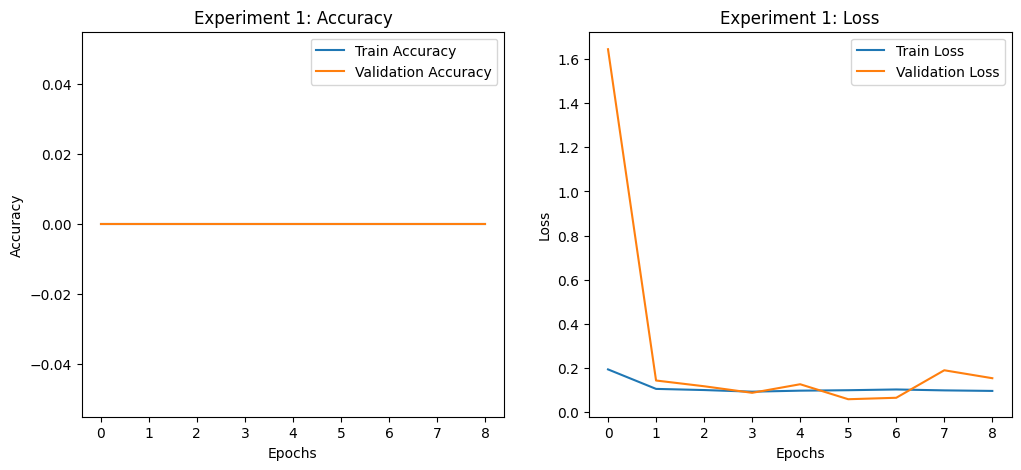


Experiment 2: {'learning_rate': 0.01, 'dropout_rate': 0.5, 'optimizer_type': 'adam'}
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0000e+00 - loss: 0.1709 - val_accuracy: 0.0000e+00 - val_loss: 6.0630 - learning_rate: 0.0100
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1009 - val_accuracy: 0.0000e+00 - val_loss: 0.1109 - learning_rate: 0.0100
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0971 - val_accuracy: 0.0000e+00 - val_loss: 0.2467 - learning_rate: 0.0100
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0909 - val_accuracy: 0.0000e+00 - val_loss: 0.0889 - learning_rate: 0.0100
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0988 - val_accuracy: 0.0000e+00 - val_loss: 2.2773 - learning_rate: 0.0100
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0901 - val_accuracy: 0.0000e+00 - val_loss: 0.2968 - learning_rate: 0.0100
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0

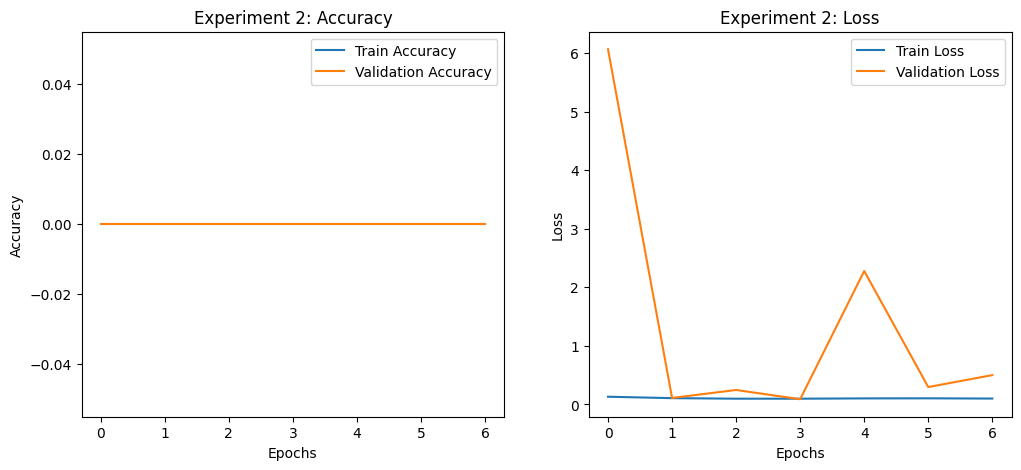


Experiment 3: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'optimizer_type': 'sgd'}
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0000e+00 - loss: 0.3336 - val_accuracy: 0.0000e+00 - val_loss: 0.7559 - learning_rate: 0.0010
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1322 - val_accuracy: 0.0000e+00 - val_loss: 0.1104 - learning_rate: 0.0010
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1086 - val_accuracy: 0.0000e+00 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: 0.1184 - val_accuracy: 0.0000e+00 - val_loss: 0.0813 - learning_rate: 0.0010
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: 0.1309 - val_accuracy: 0.0000e+00 - val_loss: 0.1488 - learning_rate: 0.0010
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0994 - val_accuracy: 0.0000e+00 - val_loss: 0.0628 - learning_rate: 5.0000e-04
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accura

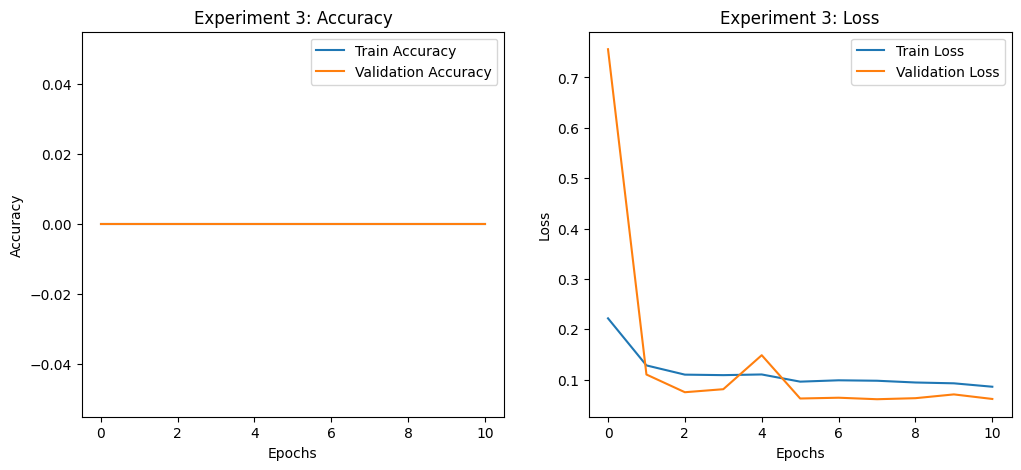

In [33]:
def experiment_with_hyperparameters():
    experiments = [
        {'learning_rate': 0.001, 'dropout_rate': 0.3, 'optimizer_type': 'adam'},
        {'learning_rate': 0.01, 'dropout_rate': 0.5, 'optimizer_type': 'adam'},
        {'learning_rate': 0.001, 'dropout_rate': 0.3, 'optimizer_type': 'sgd'},
    ]

    for i, exp in enumerate(experiments):
        print(f"\nExperiment {i+1}: {exp}")

        model = create_optimized_model(
            learning_rate=exp['learning_rate'],
            optimizer_type=exp['optimizer_type'],
            dropout_rate=exp['dropout_rate']
        )

        # Early stopping and learning rate reduction on plateau
        early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

        history = model.fit(
            X_train, y_train, validation_data=(X_val, y_val),
            epochs=50, batch_size=32, callbacks=[early_stopping, reduce_lr], verbose=1
        )

        plot_training_history(history, f"Experiment {i+1}")

experiment_with_hyperparameters()

In [35]:
def predict_gender(model, input_data):

    input_data_scaled = scaler_standard.transform(np.array([input_data]))

    # Predict gender
    prediction = model.predict(input_data_scaled)
    return 'Male' if prediction[0][0] >= 0.5 else 'Female'

example_input = [1, 14, 11, 0, 1, 0, 10]
gender_prediction = predict_gender(model, example_input)
print(f"Predicted Gender: {gender_prediction}")

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Gender: Male
